In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Generate a linearly separable dataset ###########################
X, y = make_classification(
    n_samples=300,        # total points
    n_features=2,         # two features for easy plotting
    n_informative=2,      # both features contribute to classification
    n_redundant=0,        # no redundant features
    n_clusters_per_class=1,
    class_sep=2.5,        # increase to make separation obvious
    flip_y=0,             # no label noise
    random_state=42
)
####################################################################

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [2]:
# Look at first few rows of training set to infer structure
print(f"{'Row':>4} {'Class':>6} {'Feature 1':>10} {'Feature 2':>10}")
for i in range(10):
    print(f"{i:>4} {y_train[i]:>6} {X_train[i][0]:>10.3f} {X_train[i][1]:>10.3f}")

 Row  Class  Feature 1  Feature 2
   0      1      3.171      2.466
   1      1      2.441      2.381
   2      1      2.270      2.693
   3      1      2.346      2.556
   4      1      1.948      3.269
   5      1      2.647      2.252
   6      0      2.896     -1.615
   7      1      1.832      3.197
   8      1      2.537      2.467
   9      0      2.068     -3.156


In [3]:
# Fit a linear SVM
clf_linear = SVC(kernel='linear', C=1.0)
clf_linear.fit(X_train, y_train);

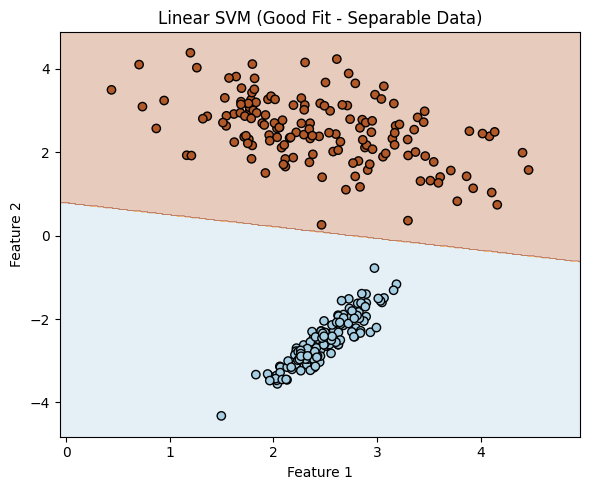

In [4]:
# Function to plot decision boundary
def plot_linear_boundary(clf, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

# Plot the linear boundary
plt.figure(figsize=(6, 5))
plot_linear_boundary(clf_linear, "Linear SVM (Good Fit - Separable Data)")
plt.tight_layout()
plt.show()

Recovered Decision Boundary from Model Coefficients:
  Weight vector: w = [0.323, 1.138]
  Intercept: b = -0.890

Decision boundary equation:
  x2 = (-0.284) * x1 + (0.782)


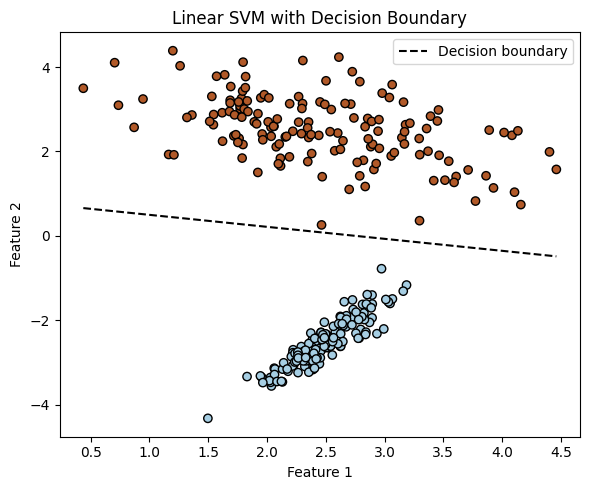

In [5]:
# Assume clf_linear is a trained linear SVM (from the 2D example)
w = clf_linear.coef_[0]
b = clf_linear.intercept_[0]

slope = -w[0] / w[1]
intercept = -b / w[1]

# Display the actual boundary equation
print("Recovered Decision Boundary from Model Coefficients:")
print(f"  Weight vector: w = [{w[0]:.3f}, {w[1]:.3f}]")
print(f"  Intercept: b = {b:.3f}")
print(f"\nDecision boundary equation:")
print(f"  x2 = ({slope:.3f}) * x1 + ({intercept:.3f})")
# Add the decision boundary to your plot
def plot_with_boundary(clf, X, y):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolors='k')
    
    w = clf.coef_[0]
    b = clf.intercept_[0]
    x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_vals = -(w[0] * x_vals + b) / w[1]
    
    plt.plot(x_vals, y_vals, 'k--', label='Decision boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Linear SVM with Decision Boundary')
    plt.legend()

# Call this after fitting the linear SVM
plt.figure(figsize=(6, 5))
plot_with_boundary(clf_linear, X, y)
plt.tight_layout()
plt.show()


Linear SVM Model
Slope : 0.3008066025908663
Intercept : 2533.0677132863866


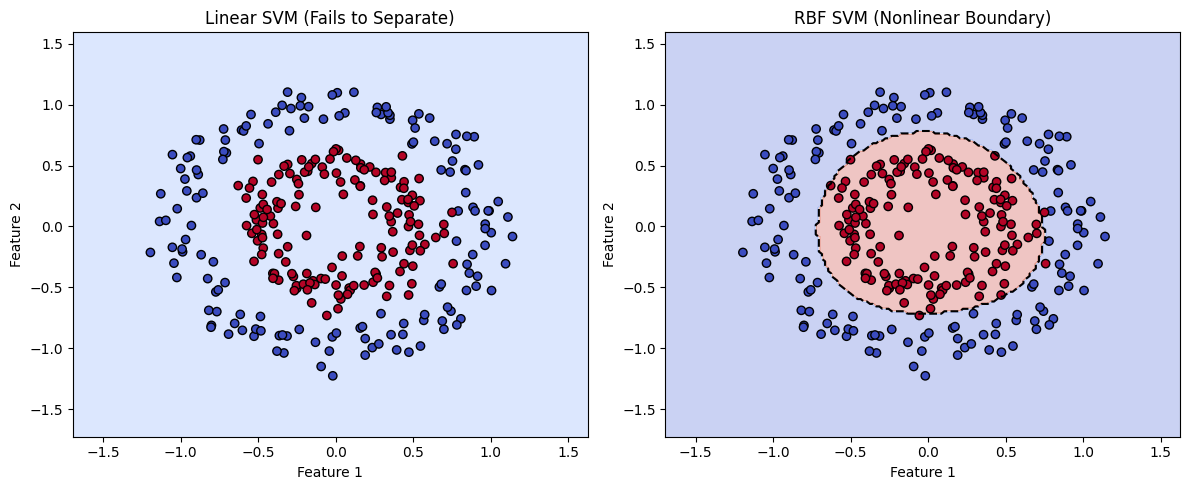

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Step 1: Generate concentric circle data (nonlinear pattern)
X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=42)

# Step 2: Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Step 3: Train linear and RBF SVMs
clf_linear = SVC(kernel='linear', C=1.0)
clf_rbf = SVC(kernel='rbf', gamma='scale', C=1.0)

clf_linear.fit(X_train, y_train)
clf_rbf.fit(X_train, y_train)

# recover the linear separation line
w = clf_linear.coef_[0]
b = clf_linear.intercept_[0]

slope = -w[0] / w[1]
intercept = -b / w[1]

print("Linear SVM Model")
print("Slope :",slope)
print("Intercept :",intercept)

# Step 4: Plotting function with decision boundary
def plot_decision_boundary(clf, title, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and data points
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linestyles='--', linewidths=1.5)  # decision boundary
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

# Step 5: Create side-by-side comparison plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(clf_linear, "Linear SVM (Fails to Separate)", X, y)

plt.subplot(1, 2, 2)
plot_decision_boundary(clf_rbf, "RBF SVM (Nonlinear Boundary)", X, y)

plt.tight_layout()
plt.show()


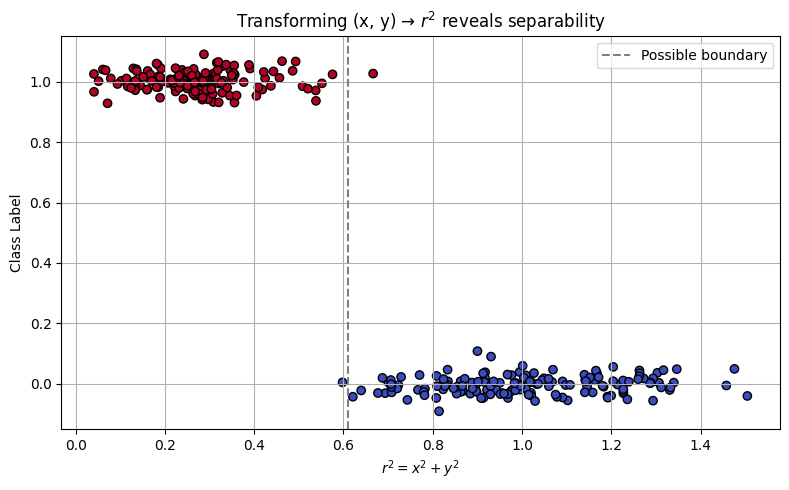

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Step 1: Generate nonlinear, concentric data
X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=42)

# Step 2: Compute r^2 for each point (distance from origin squared)
r_squared = np.sum(X**2, axis=1)  # x^2 + y^2

# Step 3: Scatter plot: r^2 vs class label
plt.figure(figsize=(8, 5))
plt.scatter(r_squared, y + np.random.normal(0, 0.03, size=len(y)), c=y, cmap='coolwarm', edgecolors='k')
plt.axvline(x=np.median(r_squared), color='gray', linestyle='--', label='Possible boundary')
plt.xlabel(r"$r^2 = x^2 + y^2$")
plt.ylabel("Class Label")
plt.title("Transforming (x, y) → $r^2$ reveals separability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Support Vector Machine Classifier
Training Accuracy: 1.0


Test Accuracy: 1.0
New mushroom classified as EDIBLE


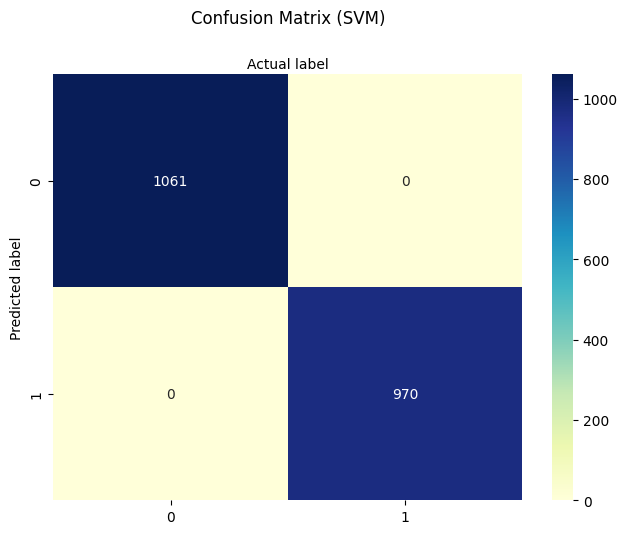

In [8]:
# SVM-Based Mushroom Classification (Refactored Version)
# Author: Sensei + OpenAI Refactor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics

# -------------------------------------------
# Step 1: Load and Prepare the Data
# -------------------------------------------
# Download the mushroom dataset from remote source
import requests
remote_url = "http://54.243.252.9/ce-5319-webroot/ce5319jb/lessons/logisticregression/agaricus-lepiota.data"
rget = requests.get(remote_url, allow_redirects=True)
with open('poisonmushroom.csv', 'wb') as localfile:
    localfile.write(rget.content)

# Define encodings for ordinal representation
encodings = {
    'poison-class':               (['e', 'p'], 0),
    'cap-shape':                  (['b','c','x','f','k','s'], 1),
    'cap-surface':                (['f','g','y','s'], 1),
    'cap-color':                  (['n','b','c','g','r','p','u','e','w','y'], 1),
    'bruises':                    (['f','t'], 1),
    'odor':                       (['a','l','c','y','f','m','n','p','s'], 1),
    'gill-attachment':            (['a','d','f','n'], 1),
    'gill-spacing':              (['c','w','d'], 1),
    'gill-size':                 (['b','n'], 1),
    'gill-color':                (['k','n','b','h','g','r','o','p','u','e','w','y'], 1),
    'stalk-shape':              (['e','t'], 1),
    'stalk-root':               (['b','c','u','e','z','r','?'], 1),
    'stalk-surface-above-ring':(['f','y','k','s','?'], 1),
    'stalk-surface-below-ring':(['f','y','k','s','?'], 1),
    'stalk-color-above-ring':  (['n','b','c','g','o','p','e','w','y'], 1),
    'stalk-color-below-ring':  (['n','b','c','g','o','p','e','w','y'], 1),
    'veil-type':               (['p','u'], 1),
    'veil-color':              (['n','o','w','y'], 1),
    'ring-number':             (['n','o','t'], 1),
    'ring-type':               (['c','e','f','l','n','p','s','z'], 1),
    'spore-print-color':       (['k','n','b','h','r','o','u','w','y','?'], 1),
    'population':              (['a','c','n','s','v','y','?'], 1),
    'habitat':                 (['g','l','m','p','u','w','d'], 1)
}

# Load data
mymushroom = pd.read_csv('poisonmushroom.csv', header=None)
mymushroom.columns = list(encodings.keys())

# Encoding helper function
def make_encoder(alphabet, offset=1, name='feature'):
    def encoder(val):
        if val in alphabet:
            return alphabet.index(val) + offset
        raise Exception(f"Encoding failed in '{name}': unknown value '{val}'")
    return encoder

# Apply encodings to dataframe
def apply_encodings(df, encodings):
    encoded_df = pd.DataFrame(index=df.index)
    for col, (alphabet, offset) in encodings.items():
        encoder = make_encoder(alphabet, offset, col)
        encoded_df[col] = df[col].apply(encoder)
    return encoded_df

interim = apply_encodings(mymushroom.copy(), encodings)

# -------------------------------------------
# Step 2: Split Data for Training/Testing
# -------------------------------------------
feature_cols = interim.columns[1:]  # all but target
X = interim[feature_cols]
y = interim['poison-class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# -------------------------------------------
# Step 3: Train SVM Classifier
# -------------------------------------------
#svm = SVC(kernel='linear', C=1.0, gamma='scale', probability=True) # this kernel OK with these settings
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
#svm = SVC(kernel='sigmoid', coef0=0.9, C=1.0, gamma='scale', probability=True) # this kernel performs poorly this dataset
#svm = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', probability=True) # this kernel works nicely with these settings
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

# -------------------------------------------
# Step 4: Evaluate Performance
# -------------------------------------------
print("Support Vector Machine Classifier")
print("Training Accuracy:", svm.score(X_train, y_train))
print("Test Accuracy:", svm.score(X_test, y_test))

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
class_names = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion Matrix (SVM)', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label')

# -------------------------------------------
# Step 5: Classify New Mushroom
# -------------------------------------------
s_new = "csgfnfwbktrssggpwoeksu"  # new sample string
feature_names = list(encodings.keys())[1:]  # skip poison-class
encoders = {key: make_encoder(alphabet, offset, key) for key, (alphabet, offset) in encodings.items() if key != 'poison-class'}

try:
    x_new = [encoders[col](char) for col, char in zip(feature_names, s_new)]
    y_new = svm.predict(np.array(x_new).reshape(1, -1))
    if y_new[0] == 0:
        print("\033[92mNew mushroom classified as EDIBLE\033[0m")
    else:
        print("\033[91mNew mushroom classified as POISONOUS\033[0m")
except Exception as e:
    print("Error encoding new sample:", e)


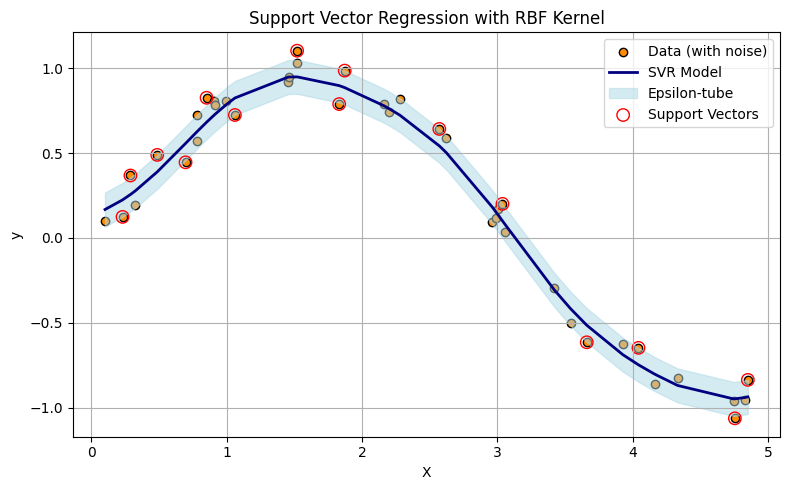

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Step 1: Generate synthetic 1D data
np.random.seed(42)
X = np.sort(5 * np.random.rand(40, 1), axis=0)          # 40 values in [0, 5]
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])  # y = sin(x) + noise

# Step 2: Fit Support Vector Regression with RBF kernel
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.5, epsilon=0.1)
svr_rbf.fit(X, y)
y_pred = svr_rbf.predict(X)

# Step 3: Plot results
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='darkorange', label='Data (with noise)', edgecolors='k')
plt.plot(X, y_pred, color='navy', lw=2, label='SVR Model')
plt.fill_between(X.ravel(),
                 y_pred - svr_rbf.epsilon,
                 y_pred + svr_rbf.epsilon,
                 color='lightblue', alpha=0.5,
                 label='Epsilon-tube')

# Highlight support vectors
plt.scatter(X[svr_rbf.support_], y[svr_rbf.support_], 
            facecolors='none', edgecolors='red', label='Support Vectors', s=80)

plt.title("Support Vector Regression with RBF Kernel")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
